In [1]:
#Import all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

Data Loaded Successfully!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 1

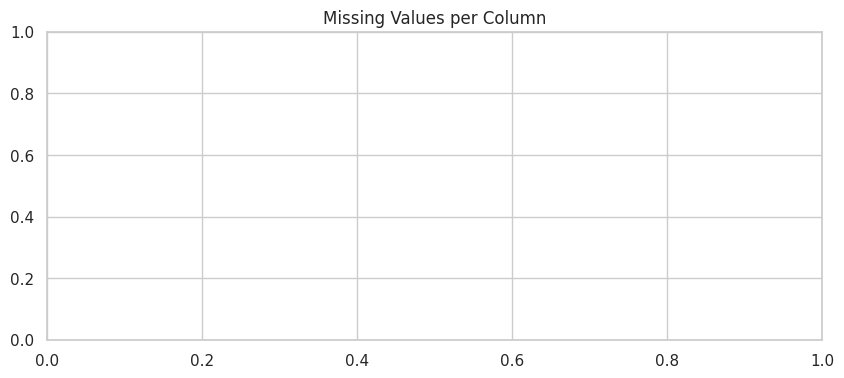

In [2]:
#Load and Inspect Data

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Employee%20Attrition.csv"
df = pd.read_csv(url)

print("Data Loaded Successfully!\n")
print(df.info(), "\n")
print(df.describe().T.head())

# Missing values visualization
missing = df.isnull().sum()
plt.figure(figsize=(10,4))
sns.barplot(x=missing[missing > 0].index, y=missing[missing > 0].values, palette="mako")
plt.title("Missing Values per Column")
plt.show()

Basic Employee Statistics:
Total employees: 1470
Attrition rate: 16.12%
Average Age: 36.9
Average Tenure (YearsAtCompany): 7.0
Average Monthly Income: 6503


/tmp/ipython-input-3143425595.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='coolwarm')


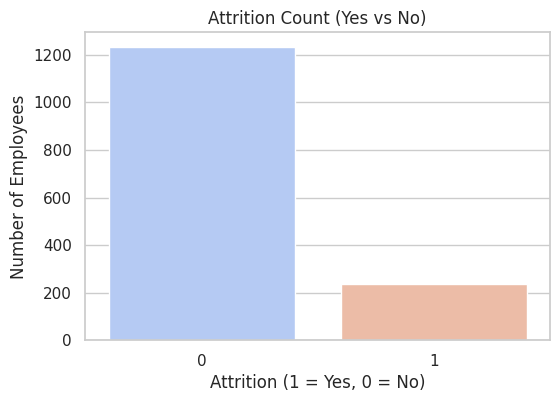

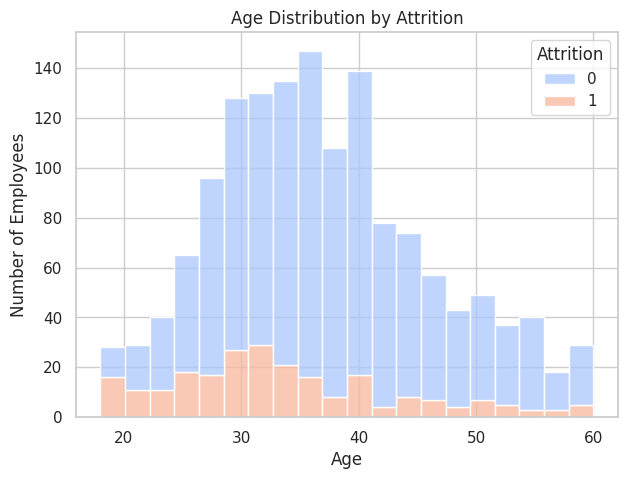

/tmp/ipython-input-3143425595.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='coolwarm')


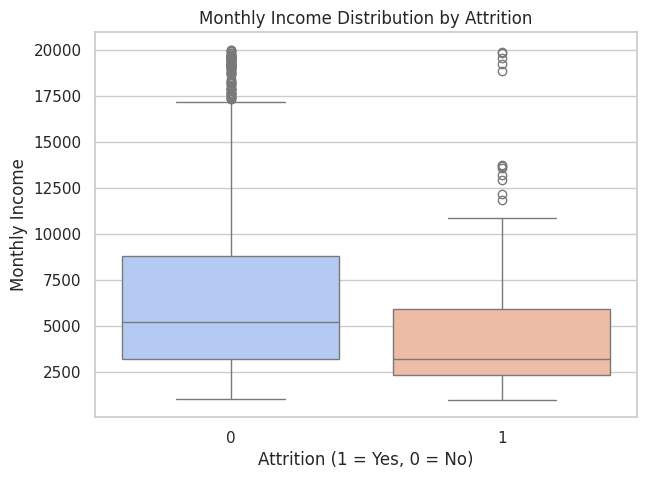

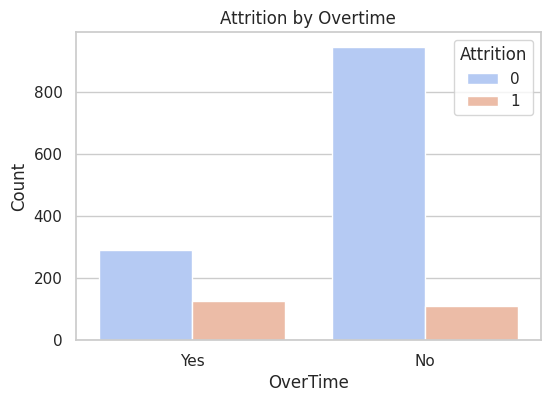

/tmp/ipython-input-3143425595.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='JobSatisfaction', palette='coolwarm')


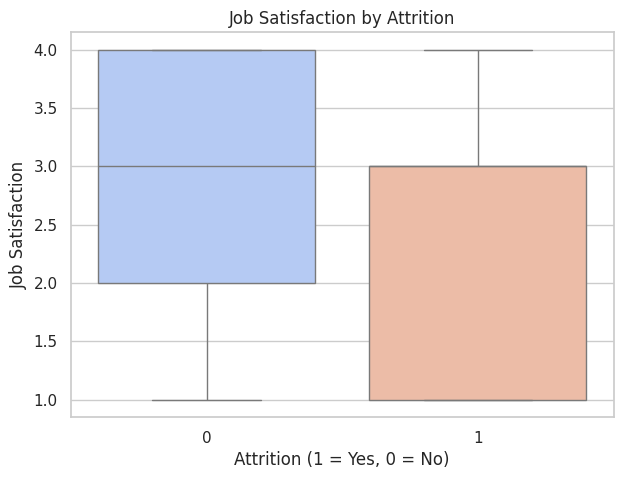

In [3]:
# Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Attrition to numeric
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# safely compute summary stats
print("Basic Employee Statistics:")
print(f"Total employees: {len(df)}")

if df['Attrition'].notna().sum() > 0:
    print(f"Attrition rate: {df['Attrition'].mean() * 100:.2f}%")
else:
    print("Attrition rate: Data missing or invalid")

print(f"Average Age: {df['Age'].mean():.1f}")
print(f"Average Tenure (YearsAtCompany): {df['YearsAtCompany'].mean():.1f}")
print(f"Average Monthly Income: {df['MonthlyIncome'].mean():.0f}")


# Attrition Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Attrition', palette='coolwarm')
plt.title('Attrition Count (Yes vs No)')
plt.xlabel('Attrition (1 = Yes, 0 = No)')
plt.ylabel('Number of Employees')
plt.show()

#Age Distribution by Attrition
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack', bins=20, palette='coolwarm')
plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

# Monthly Income vs Attrition
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='coolwarm')
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Attrition (1 = Yes, 0 = No)')
plt.ylabel('Monthly Income')
plt.show()

# Overtime vs Attrition
if 'OverTime' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='OverTime', hue='Attrition', palette='coolwarm')
    plt.title('Attrition by Overtime')
    plt.xlabel('OverTime')
    plt.ylabel('Count')
    plt.show()

# Job Satisfaction vs Attrition
if 'JobSatisfaction' in df.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x='Attrition', y='JobSatisfaction', palette='coolwarm')
    plt.title('Job Satisfaction by Attrition')
    plt.xlabel('Attrition (1 = Yes, 0 = No)')
    plt.ylabel('Job Satisfaction')
    plt.show()




Unique Attrition values: [1 0]
Missing Attrition values: 0
Added new window-based features successfully


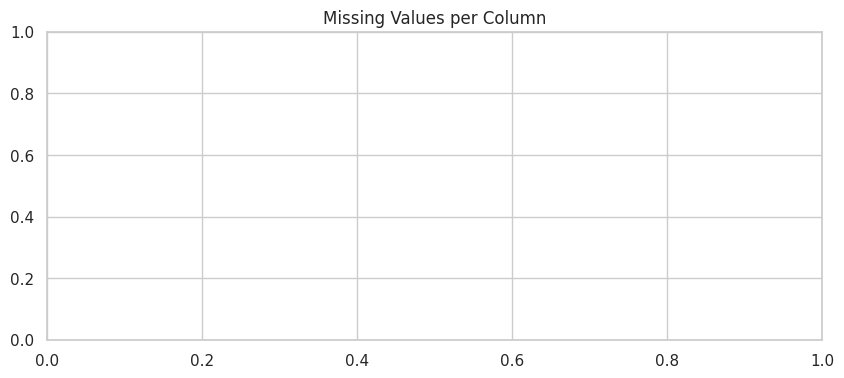

In [4]:
#Clean Columns and Encode Attrition

df.columns = df.columns.str.strip()

# Handle Attrition safely
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].astype(str).str.strip().str.title()
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
else:
    df['Attrition'] = df['Attrition'].astype(int)

print("\nUnique Attrition values:", df['Attrition'].unique())
print("Missing Attrition values:", df['Attrition'].isna().sum())

# Feature Engineering with Window Functions

# Average of MonthlyIncome by Department
df['Dept_Avg_Income'] = (
    df.groupby('Department')['MonthlyIncome']
      .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

# Rank employees by PerformanceRating within each department
df['Dept_Perf_Rank'] = (
    df.groupby('Department')['PerformanceRating']
      .rank(method='dense', ascending=False)
)

# Compute deviation from department average salary
df['Income_Dept_Deviation'] = (
    df['MonthlyIncome'] - df.groupby('Department')['MonthlyIncome'].transform('mean')
)

# Moving average of YearsAtCompany for trend-like insight
df['Rolling_YearsAtCompany'] = (
    df['YearsAtCompany'].rolling(window=3, min_periods=1).mean()
)

# Employee’s income percentile within JobRole
df['Income_Percentile_Role'] = (
    df.groupby('JobRole')['MonthlyIncome'].rank(pct=True)
)

print("Added new window-based features successfully")

# Visualize missing values
missing = df.isnull().sum()
plt.figure(figsize=(10,4))
sns.barplot(x=missing[missing > 0].index, y=missing[missing > 0].values, palette="mako")
plt.title("Missing Values per Column")
plt.show()


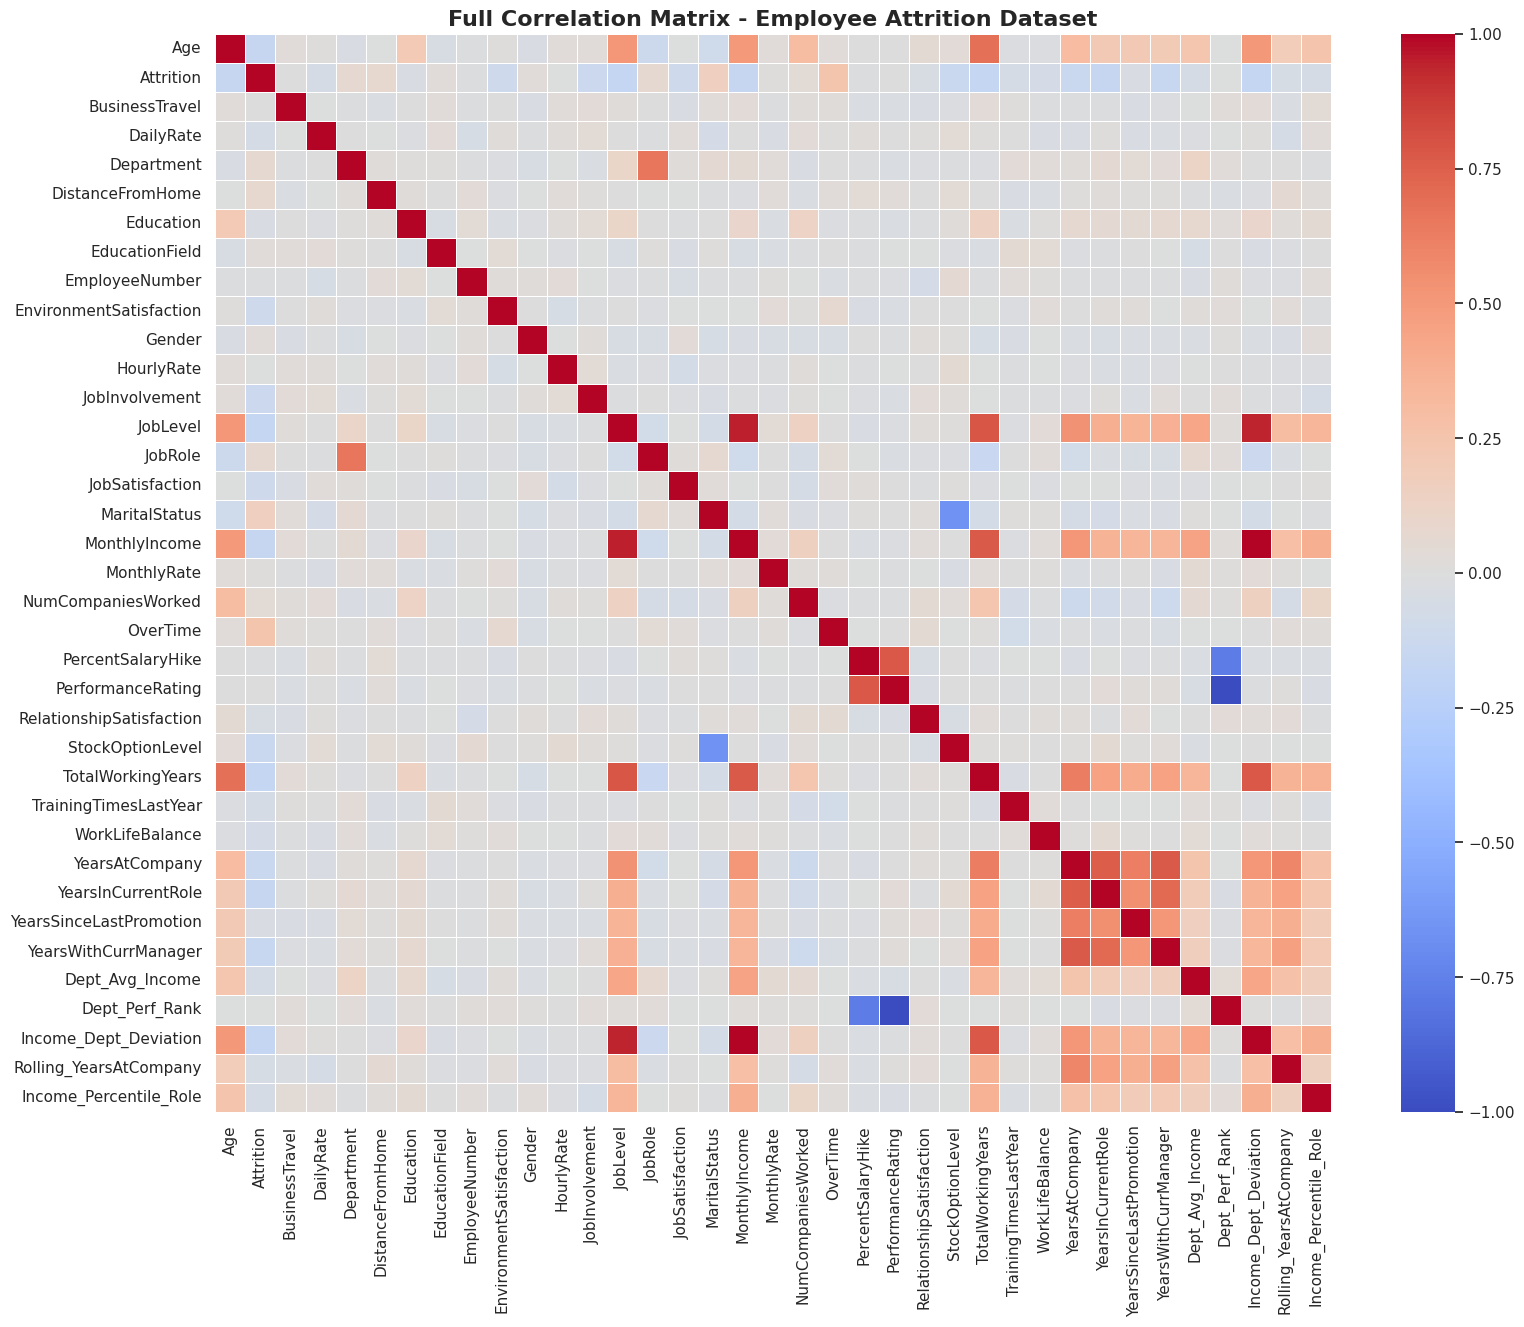

In [5]:
# Create Encoded Copy for Correlation Analysis

df_corr = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le.fit_transform(df_corr[col])

# Drop constant columns (no variance)
df_corr = df_corr.loc[:, df_corr.apply(pd.Series.nunique) > 1]

# Compute correlation matrix
corr_matrix = df_corr.corr().dropna(axis=0, how='all').dropna(axis=1, how='all')

# Visualize full correlation matrix
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Full Correlation Matrix - Employee Attrition Dataset", fontsize=16, weight='bold')
plt.show()



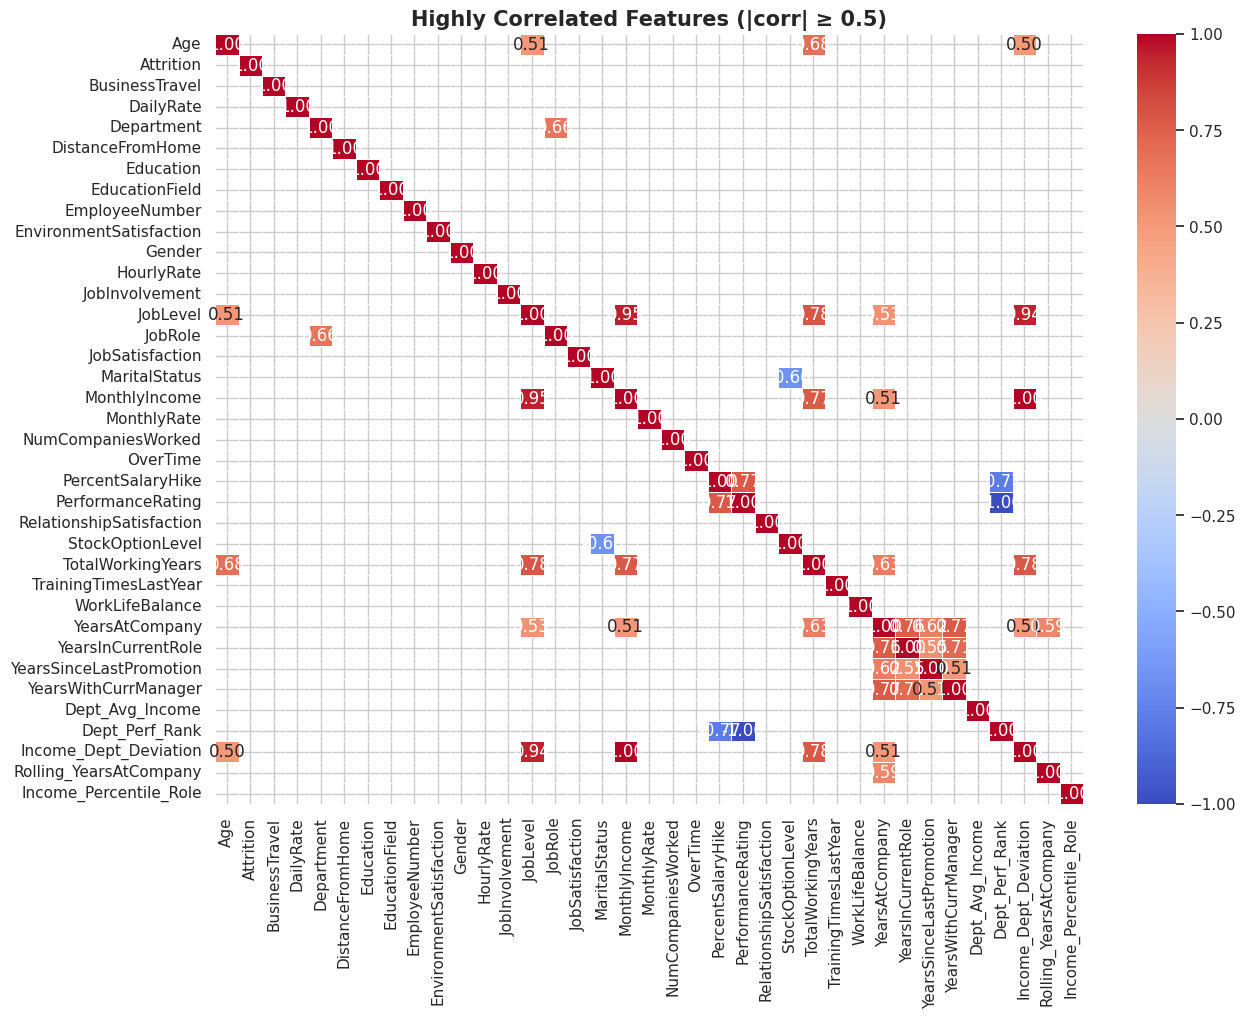


Top 10 Most Correlated Feature Pairs:

                  Feature 1              Feature 2  Correlation
1210         Dept_Perf_Rank      PerformanceRating    -1.000000
824       PerformanceRating         Dept_Perf_Rank    -1.000000
645           MonthlyIncome  Income_Dept_Deviation     0.997825
1241  Income_Dept_Deviation          MonthlyIncome     0.997825
484                JobLevel          MonthlyIncome     0.950300
625           MonthlyIncome               JobLevel     0.950300
1237  Income_Dept_Deviation               JobLevel     0.944885
501                JobLevel  Income_Dept_Deviation     0.944885
913       TotalWorkingYears               JobLevel     0.782208
492                JobLevel      TotalWorkingYears     0.782208


In [6]:
#Highly Correlated Feature Pairs

threshold = 0.5
high_corr = corr_matrix[(corr_matrix >= threshold) | (corr_matrix <= -threshold)]
high_corr = high_corr.dropna(axis=0, how='all').dropna(axis=1, how='all')

plt.figure(figsize=(14, 10))
sns.heatmap(high_corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title(f"Highly Correlated Features (|corr| ≥ {threshold})", fontsize=15, weight='bold')
plt.show()

# List top correlation pairs
corr_pairs = (
    corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
)
top_corr_pairs = corr_pairs.reindex(corr_pairs['Correlation'].abs().sort_values(ascending=False).index)

print("\nTop 10 Most Correlated Feature Pairs:\n")
print(top_corr_pairs.head(10))


In [7]:
# Scale Numeric Features

numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

print("\nScaled data shape:", scaled_data.shape)




Scaled data shape: (1470, 32)



PCA Data Check:
pca_df shape: (1470, 3)
Unique Attrition values: [1 0]


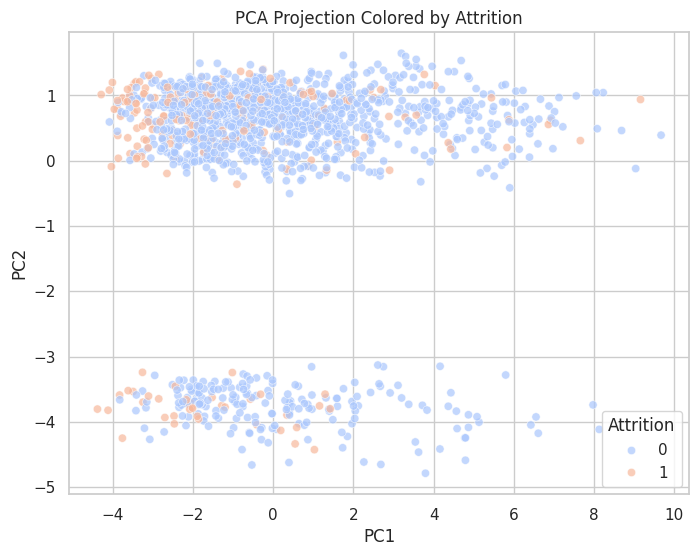

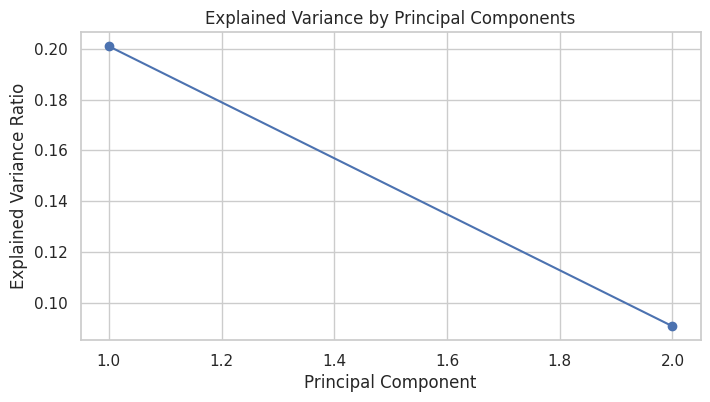

In [8]:
# Principal Component Analysis (PCA)

# Drop any residual NaNs or infs
df_num = numeric_df.replace([np.inf, -np.inf], np.nan).dropna()

# Re-scale after cleaning
scaled = scaler.fit_transform(df_num)

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

# Prepare PCA DataFrame
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=df_num.index)

# Align Attrition values
pca_df['Attrition'] = df.loc[pca_df.index, 'Attrition']

# Check data integrity
print("\nPCA Data Check:")
print("pca_df shape:", pca_df.shape)
print("Unique Attrition values:", pca_df['Attrition'].unique())

# PCA Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Attrition',
    palette='coolwarm',
    alpha=0.7
)
plt.title('PCA Projection Colored by Attrition')
plt.show()

# Explained variance
plt.figure(figsize=(8,4))
plt.plot(range(1, 3), pca.explained_variance_ratio_, 'o-')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

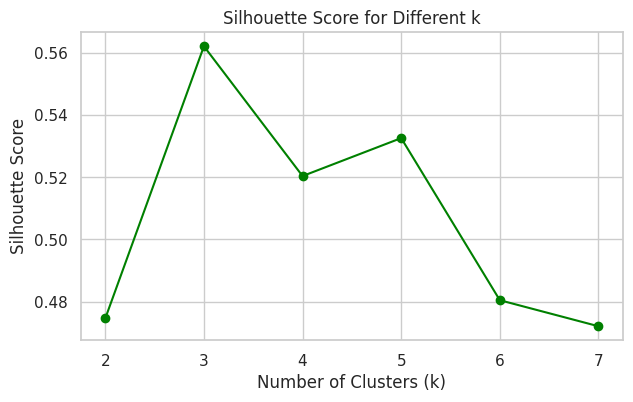

Optimal number of clusters: 3


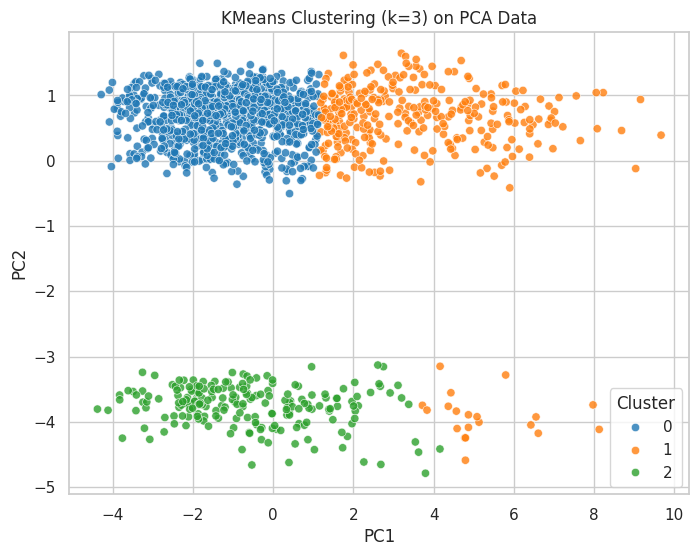

In [9]:
# KMeans Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Run KMeans for a few cluster sizes
silhouette_scores = []
K = range(2, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_df[['PC1', 'PC2']])
    score = silhouette_score(pca_df[['PC1', 'PC2']], labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(7,4))
plt.plot(K, silhouette_scores, 'o-', color='green')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

# Choose best k (highest silhouette score)
best_k = K[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {best_k}")

# Final KMeans with best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(pca_df[['PC1', 'PC2']])

# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Cluster',
    palette='tab10',
    alpha=0.8
)
plt.title(f'KMeans Clustering (k={best_k}) on PCA Data')
plt.show()


In [10]:
# Analyze cluster vs. Attrition or PerformanceRating
cluster_summary = df.loc[pca_df.index].copy()
cluster_summary['Cluster'] = pca_df['Cluster']

# Average attrition rate and performance by cluster
cluster_analysis = cluster_summary.groupby('Cluster')[['Attrition', 'PerformanceRating', 'MonthlyIncome', 'YearsAtCompany']].mean()
print(cluster_analysis)



         Attrition  PerformanceRating  MonthlyIncome  YearsAtCompany
Cluster                                                             
0         0.189956           3.000000    4431.693231        4.694323
1         0.074713           3.057471   12617.387931       13.727011
2         0.179612           4.000000    5383.626214        5.946602


In [11]:
# Classification Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ensure Attrition is numeric
df['Attrition'] = df['Attrition'].astype(int)

# Select only numeric columns except Attrition
X = df.select_dtypes(include=[np.number]).drop(columns=['Attrition'])
y = df['Attrition']

# Check shapes
print(f"Data ready for modeling:")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Unique y values: {y.unique()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate both models
print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))


Data ready for modeling:
Shape of X: (1470, 31)
Shape of y: (1470,)
Unique y values: [1 0]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.71      0.11      0.19        47

    accuracy                           0.85       294
   macro avg       0.78      0.55      0.55       294
weighted avg       0.83      0.85      0.80       294


Random Forest Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       247
           1       0.29      0.09      0.13        47

    accuracy                           0.82       294
   macro avg       0.57      0.52      0.52       294
weighted avg       0.76      0.82      0.78       294



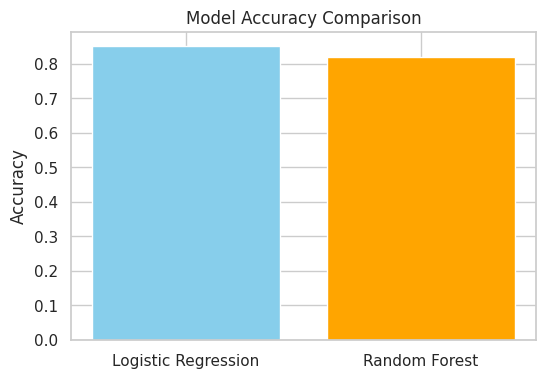

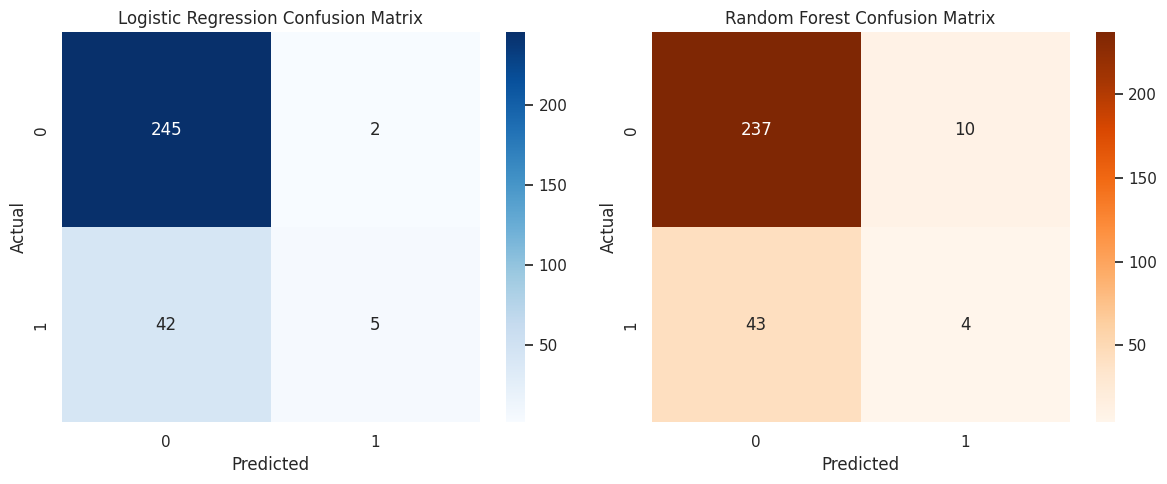

In [12]:
# Model Performance Comparison
import numpy as np

# Compute accuracies
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

# Bar chart for accuracy
plt.figure(figsize=(6,4))
plt.bar(['Logistic Regression', 'Random Forest'], [acc_lr, acc_rf], color=['skyblue','orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()
